# GitHub Machine Learning Repository Analysis

**Student Data Analysis Project**

This notebook is the single master project file. It uses the GitHub Search Repositories API to collect repositories matching `machine learning`, prepares the data with pandas, stores it in SQLite, analyzes it with SQL, creates Matplotlib visualizations, and explains the findings in simple language.

The project is intentionally kept at a beginner-to-intermediate student level. The code is straightforward and every major decision is explained so that the work can be understood and presented to a teacher.

## Project question

What patterns can we find in the popularity, programming languages, licenses, and activity dates of public GitHub repositories related to machine learning?

The analysis uses a snapshot of up to 100 repositories returned by the GitHub Search Repositories API. Because GitHub data changes over time, the raw response is saved with the project files and the collection date is recorded during execution.

## Rubric map

| Rubric requirement | Notebook location | Status |
|---|---|---|
| Retrieve repository data from GitHub API | Data Collection section | Complete |
| Convert JSON response to pandas DataFrame | Data Collection section | Complete |
| Explore the dataset | Data Exploration section | Complete |
| Select required columns | Data Cleaning section | Complete |
| Extract nested owner and license values | Data Cleaning section | Complete |
| Handle missing values | Data Cleaning section | Complete |
| Detect and remove duplicates | Data Cleaning section | Complete |
| Convert dates and rename columns | Data Cleaning section | Complete |
| Save and verify `github_projects.csv` | Data Cleaning section | Complete |
| Create SQLite database and `Repositories` table | SQL section | Complete |
| Filtering and searching queries | SQL Query 1 | Complete |
| Use `AND`, `OR`, and `NOT` | SQL Query 2 | Complete |
| Sorting and limiting queries | SQL Queries 1–3 | Complete |
| Aggregate functions such as `COUNT` and `AVG` | SQL Query 4 | Complete |
| `GROUP BY` and `HAVING` | SQL Queries 5–6 | Complete |
| Matplotlib visualizations | Visualization section | Complete |
| Interpret analysis results | Findings section | Complete |
| Git and GitHub evidence | Submission section | Pending external upload |
| Ethics reflection | Ethics section | Complete |


## 1. Data source and collection plan

The data source is the official GitHub Search Repositories API. The endpoint searches for `machine learning`, sorts by stars in descending order, and requests up to 100 results. The API response has a top-level `items` list containing repository records.

Important fields include repository name, owner, description, programming language, stars, watchers, forks, open issues, license, fork status, and creation/update dates. The nested fields `owner.login` and `license.name` will be extracted before the dataset is saved.

**API link:** https://api.github.com/search/repositories?q=machine+learning&sort=stars&order=desc&per_page=100

The GitHub documentation explains the Search API here: https://docs.github.com/en/rest/search/search?apiVersion=2022-11-28#search-repositories

In [1]:
from pathlib import Path
import json
import sqlite3
import requests
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_DIR = Path.cwd()
RAW_DIR = PROJECT_DIR / "data" / "raw"
CLEAN_DIR = PROJECT_DIR / "data" / "clean"
FIGURES_DIR = PROJECT_DIR / "figures"
RAW_DIR.mkdir(parents=True, exist_ok=True)
CLEAN_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

API_URL = (
    "https://api.github.com/search/repositories"
    "?q=machine+learning&sort=stars&order=desc&per_page=100"
)
RAW_JSON_PATH = RAW_DIR / "github_repositories_raw.json"
CLEAN_CSV_PATH = CLEAN_DIR / "github_projects.csv"
DB_PATH = PROJECT_DIR / "github_projects.sqlite"

## 2. Data collection

We request the real API response and check that the request succeeded. We save the original JSON before cleaning so that the analysis can be reproduced and audited.

In [2]:
response = requests.get(
    API_URL,
    headers={
        "Accept": "application/vnd.github+json",
        "X-GitHub-Api-Version": "2022-11-28",
        "User-Agent": "student-data-analysis-project",
    },
    timeout=30,
)
response.raise_for_status()
data = response.json()
RAW_JSON_PATH.write_text(json.dumps(data, indent=2), encoding="utf-8")

print("API status code:", response.status_code)
print("Top-level keys:", list(data.keys()))
print("API total_count:", data.get("total_count"))
print("Incomplete results:", data.get("incomplete_results"))

API status code: 200
Top-level keys: ['total_count', 'incomplete_results', 'items']
API total_count: 1244742
Incomplete results: False


In [3]:
repositories = data["items"]
raw_df = pd.DataFrame(repositories)
print("Number of returned repositories:", len(raw_df))
print("Raw dataset shape:", raw_df.shape)
print(raw_df.head(3).to_string())

Number of returned repositories: 100
Raw dataset shape: (100, 82)
          id                           node_id              name                   full_name  private                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 

## 3. Data exploration and cleaning

The raw response includes many API metadata fields. We keep only the columns needed for the project. Missing language and license values are kept as meaningful categories instead of deleting valid repositories. Duplicate repository IDs are removed if they occur. Dates are converted into date values, and count columns are checked for invalid negative values.

In [4]:
clean_df = pd.DataFrame({
    "repository_id": raw_df["id"],
    "repository_name": raw_df["name"],
    "full_name": raw_df["full_name"],
    "owner_name": raw_df["owner"].apply(lambda value: value.get("login") if isinstance(value, dict) else None),
    "description": raw_df["description"],
    "repository_url": raw_df["html_url"],
    "primary_language": raw_df["language"],
    "stars": raw_df["stargazers_count"],
    "watchers": raw_df["watchers_count"],
    "forks": raw_df["forks_count"],
    "open_issues": raw_df["open_issues_count"],
    "license_name": raw_df["license"].apply(lambda value: value.get("name") if isinstance(value, dict) else None),
    "is_fork": raw_df["fork"],
    "created_date": pd.to_datetime(raw_df["created_at"], errors="coerce", utc=True).dt.date,
    "updated_date": pd.to_datetime(raw_df["updated_at"], errors="coerce", utc=True).dt.date,
})

print("Missing values before cleaning:")
print(clean_df.isna().sum())
print("Duplicate rows before cleaning:", clean_df.duplicated().sum())
print("Duplicate repository IDs before cleaning:", clean_df["repository_id"].duplicated().sum())

Missing values before cleaning:
repository_id        0
repository_name      0
full_name            0
owner_name           0
description          0
repository_url       0
primary_language    23
stars                0
watchers             0
forks                0
open_issues          0
license_name        22
is_fork              0
created_date         0
updated_date         0
dtype: int64
Duplicate rows before cleaning: 0
Duplicate repository IDs before cleaning: 0


In [5]:
clean_df = clean_df.drop_duplicates()
clean_df = clean_df.drop_duplicates(subset="repository_id")

clean_df["description"] = clean_df["description"].fillna("No description")
clean_df["primary_language"] = clean_df["primary_language"].fillna("Unknown")
clean_df["license_name"] = clean_df["license_name"].fillna("No license listed")

numeric_columns = ["repository_id", "stars", "watchers", "forks", "open_issues"]
for column in numeric_columns:
    clean_df[column] = pd.to_numeric(clean_df[column], errors="coerce")

negative_counts = (clean_df[["stars", "watchers", "forks", "open_issues"]] < 0).sum()
print("Negative values:")
print(negative_counts)
print("Missing values after cleaning:")
print(clean_df.isna().sum())
print("Duplicate rows after cleaning:", clean_df.duplicated().sum())
print("Duplicate repository IDs after cleaning:", clean_df["repository_id"].duplicated().sum())

clean_df.to_csv(CLEAN_CSV_PATH, index=False)
print("Saved cleaned dataset to:", CLEAN_CSV_PATH)
print("Cleaned dataset shape:", clean_df.shape)

Negative values:
stars          0
watchers       0
forks          0
open_issues    0
dtype: int64
Missing values after cleaning:
repository_id       0
repository_name     0
full_name           0
owner_name          0
description         0
repository_url      0
primary_language    0
stars               0
watchers            0
forks               0
open_issues         0
license_name        0
is_fork             0
created_date        0
updated_date        0
dtype: int64
Duplicate rows after cleaning: 0
Duplicate repository IDs after cleaning: 0
Saved cleaned dataset to: /home/ubuntu/projects/analysis-bdeac743/data/clean/github_projects.csv
Cleaned dataset shape: (100, 15)


## 4. SQLite database and SQL analysis

## SQL analysis questions and explanations

The SQL section uses one SQLite table named `Repositories`, created directly from `github_projects.csv`. Query 1 demonstrates filtering with `WHERE`, sorting, and `AND`. Query 2 demonstrates the required `AND`, `OR`, and `NOT` logical operators. Query 3 demonstrates sorting and limiting. Query 4 uses `COUNT` and `AVG`. Queries 5 and 6 use `GROUP BY` and `HAVING` to summarize categories and keep only groups meeting a minimum size.

The output printed by each code cell is the actual result from the saved cleaned dataset.

## Visualization questions

The first chart answers which repositories have the most stars, so a horizontal bar chart is appropriate for comparing repository names. The second chart answers which primary languages appear most often, so a bar chart is appropriate for category counts. The third chart examines whether repositories with more stars also tend to have more forks. Logarithmic axes are used because repository counts are strongly uneven, and the axis labels clearly state this choice.

In [6]:
# Create the SQLite database and import the cleaned CSV.
connection = sqlite3.connect(DB_PATH)
clean_df.to_sql("Repositories", connection, if_exists="replace", index=False)

print("Database created:", DB_PATH.exists())
print("Rows imported:", pd.read_sql_query("SELECT COUNT(*) AS row_count FROM Repositories", connection).iloc[0, 0])
print("Table columns:")
print(pd.read_sql_query("PRAGMA table_info(Repositories)", connection)[["name", "type"]].to_string(index=False))

# Query 1: Filtering and searching.
print("\nQUERY 1 — Python repositories with at least 10,000 stars")
query_1 = """
SELECT repository_name, owner_name, primary_language, stars
FROM Repositories
WHERE primary_language = 'Python' AND stars >= 10000
ORDER BY stars DESC;
"""
print(pd.read_sql_query(query_1, connection).to_string(index=False))

# Query 2: AND, OR, and NOT logical operators.
print("\nQUERY 2 — Python OR Jupyter Notebook repositories that are NOT forks")
query_2 = """
SELECT repository_name, primary_language, stars, is_fork
FROM Repositories
WHERE (primary_language = 'Python' OR primary_language = 'Jupyter Notebook')
  AND NOT is_fork
ORDER BY stars DESC
LIMIT 10;
"""
print(pd.read_sql_query(query_2, connection).to_string(index=False))

# Query 3: Sorting and limiting.
print("\nQUERY 3 — Ten most-starred repositories")
query_3 = """
SELECT repository_name, stars, forks
FROM Repositories
ORDER BY stars DESC
LIMIT 10;
"""
print(pd.read_sql_query(query_3, connection).to_string(index=False))

# Query 4: Aggregate functions.
print("\nQUERY 4 — Total repositories and average stars")
query_4 = """
SELECT COUNT(*) AS total_repositories,
       ROUND(AVG(stars), 2) AS average_stars,
       ROUND(AVG(forks), 2) AS average_forks
FROM Repositories;
"""
print(pd.read_sql_query(query_4, connection).to_string(index=False))

# Query 5: GROUP BY and HAVING.
print("\nQUERY 5 — Language groups with at least 2 repositories")
query_5 = """
SELECT primary_language,
       COUNT(*) AS repository_count,
       ROUND(AVG(stars), 2) AS average_stars
FROM Repositories
GROUP BY primary_language
HAVING COUNT(*) >= 2
ORDER BY repository_count DESC, average_stars DESC;
"""
print(pd.read_sql_query(query_5, connection).to_string(index=False))

# Query 6: License grouping with HAVING.
print("\nQUERY 6 — Licenses used by at least 5 repositories")
query_6 = """
SELECT license_name, COUNT(*) AS repository_count
FROM Repositories
GROUP BY license_name
HAVING COUNT(*) >= 5
ORDER BY repository_count DESC;
"""
print(pd.read_sql_query(query_6, connection).to_string(index=False))


Database created: True
Rows imported: 100
Table columns:
            name    type
   repository_id INTEGER
 repository_name    TEXT
       full_name    TEXT
      owner_name    TEXT
     description    TEXT
  repository_url    TEXT
primary_language    TEXT
           stars INTEGER
        watchers INTEGER
           forks INTEGER
     open_issues INTEGER
    license_name    TEXT
         is_fork INTEGER
    created_date    DATE
    updated_date    DATE

QUERY 1 — Python repositories with at least 10,000 stars
                   repository_name      owner_name primary_language  stars
                      transformers     huggingface           Python 164670
                            funNLP  fighting41love           Python  82798
          awesome-machine-learning    josephmisiti           Python  74228
                      scikit-learn    scikit-learn           Python  67112
                            gradio      gradio-app           Python  43441
                   ML-From-Scratch 

## SQL query explanations

### Query 1 — Filtering and searching

**Question:** Which Python repositories have at least 10,000 stars?

```sql
SELECT repository_name, owner_name, primary_language, stars
FROM Repositories
WHERE primary_language = 'Python' AND stars >= 10000
ORDER BY stars DESC;
```

`SELECT` chooses the columns to display. `FROM Repositories` tells SQLite which table to use. `WHERE` filters the rows. The `AND` operator requires both conditions to be true: the language must be Python and the star count must be at least 10,000. `ORDER BY stars DESC` places the largest star counts first. The actual output is printed in the SQL code cell above.

### Query 2 — Logical operators

**Question:** Which top repositories use Python or Jupyter Notebook and are not forks?

```sql
SELECT repository_name, primary_language, stars, is_fork
FROM Repositories
WHERE (primary_language = 'Python' OR primary_language = 'Jupyter Notebook')
  AND NOT is_fork
ORDER BY stars DESC
LIMIT 10;
```

The parentheses group the `OR` condition. `AND` connects that condition to the fork condition. `NOT is_fork` excludes forked repositories. `ORDER BY` sorts the results by stars, and `LIMIT 10` keeps only the first ten rows. This query demonstrates all three required logical operators.

### Query 3 — Sorting and limiting

**Question:** What are the ten most-starred repositories?

```sql
SELECT repository_name, stars, forks
FROM Repositories
ORDER BY stars DESC
LIMIT 10;
```

The query selects three useful columns, sorts stars from highest to lowest, and returns only ten rows.

### Query 4 — Aggregate functions

**Question:** How many repositories are in the table, and what are the average stars and forks?

```sql
SELECT COUNT(*) AS total_repositories,
       ROUND(AVG(stars), 2) AS average_stars,
       ROUND(AVG(forks), 2) AS average_forks
FROM Repositories;
```

`COUNT(*)` counts every row. `AVG(stars)` and `AVG(forks)` calculate averages. `ROUND(..., 2)` keeps two decimal places so the result is easier to read. `AS` gives each result a clear name.

### Query 5 — Grouping and HAVING

**Question:** How many repositories and average stars are there for each language group with at least two repositories?

```sql
SELECT primary_language,
       COUNT(*) AS repository_count,
       ROUND(AVG(stars), 2) AS average_stars
FROM Repositories
GROUP BY primary_language
HAVING COUNT(*) >= 2
ORDER BY repository_count DESC, average_stars DESC;
```

`GROUP BY primary_language` creates one group for each language. The aggregate functions calculate a count and average inside each group. `HAVING COUNT(*) >= 2` keeps only language groups with at least two repositories. `ORDER BY` sorts larger groups first and then uses average stars as a second sorting rule.

### Query 6 — License grouping

**Question:** Which licenses appear in at least five repositories?

This query groups by `license_name`, counts the repositories in each license group, filters groups with `HAVING COUNT(*) >= 5`, and sorts the most common licenses first. It shows how the license field can be used for a simple categorical analysis.

## 5. Python analysis and Matplotlib visualizations

The charts below answer focused questions from the rubric and are saved as image files in the `figures` folder.

## Visualization explanations

### Chart 1 — Top repositories by stars

This horizontal bar chart answers which repositories have the highest star counts. A bar chart is appropriate because it makes category sizes easy to compare. A horizontal layout keeps long repository names readable. The chart shows TensorFlow at the top of this sample, followed by Transformers and ML-For-Beginners.

### Chart 2 — Repositories by primary language

This horizontal bar chart answers which primary languages appear most often. A category-count bar chart is appropriate because the variable is categorical. Python is the largest known language category, while `Unknown` is also common because GitHub did not provide a language value for those records.

### Chart 3 — Stars and forks

This scatter plot answers whether star counts and fork counts move together. A scatter plot is appropriate because both variables are numeric. Logarithmic axes are used because the counts vary greatly between repositories. The upward pattern supports the calculated positive correlation of 0.9277, but correlation does not prove that one variable causes the other.

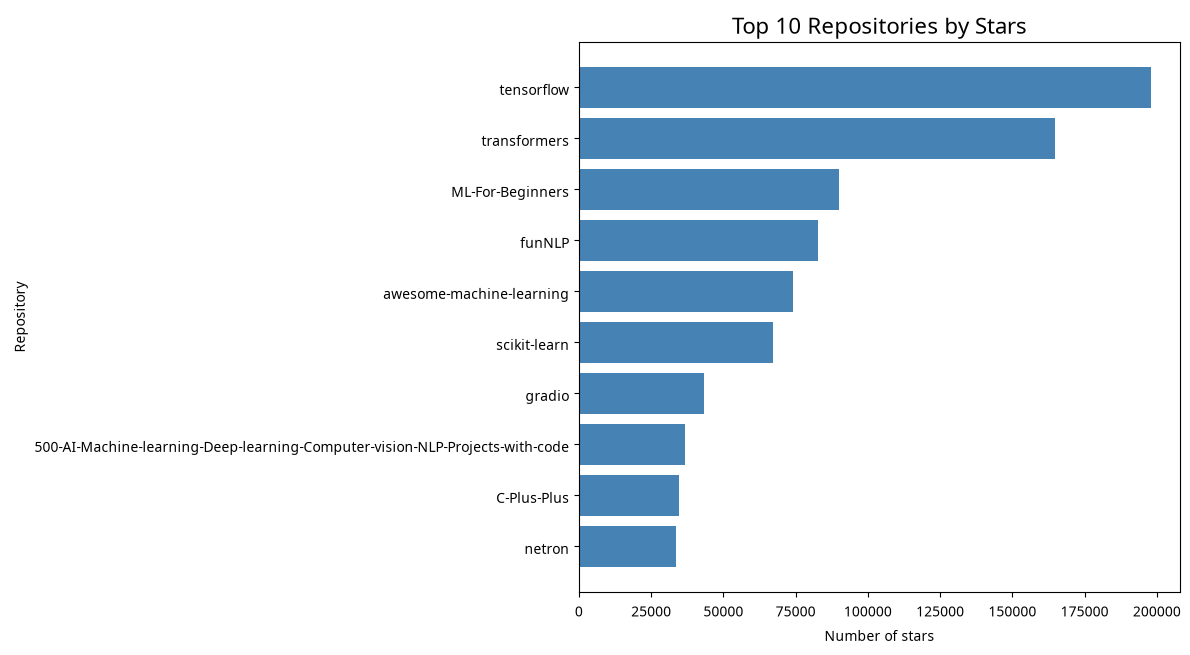

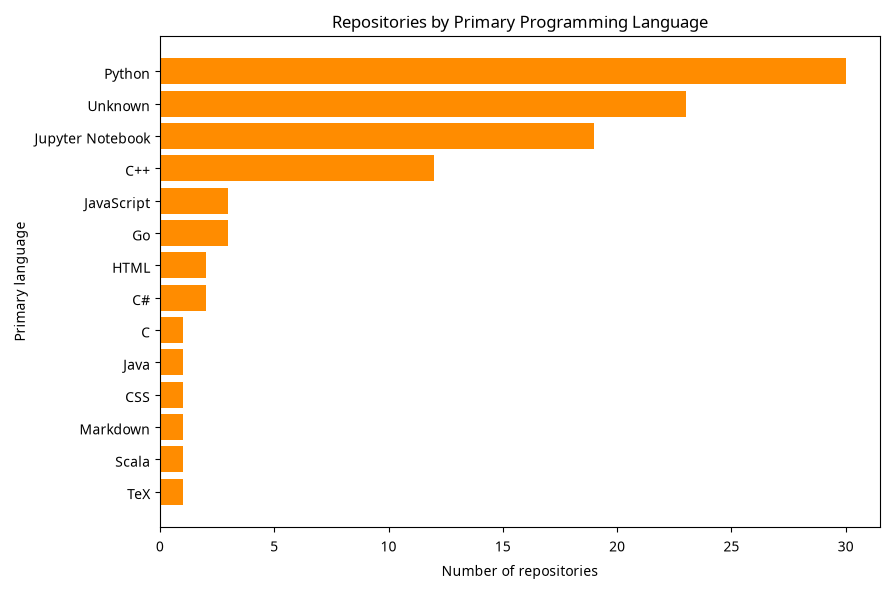

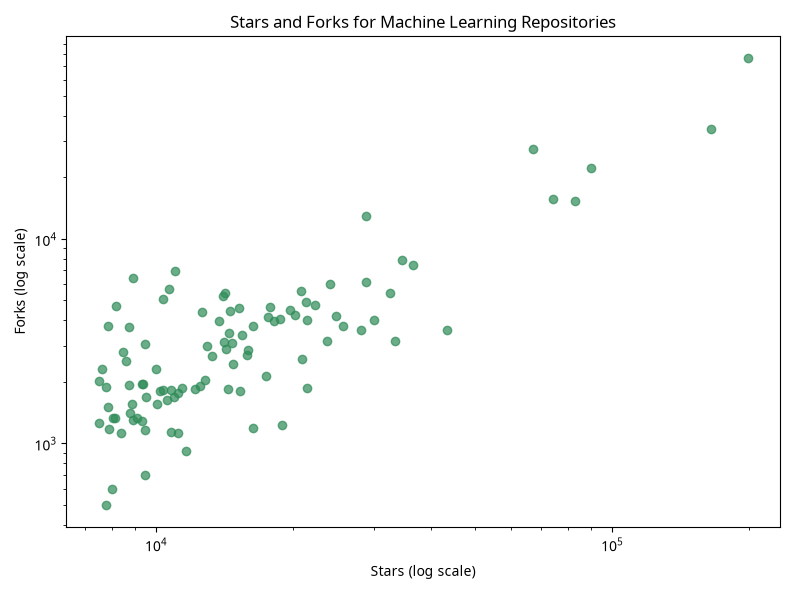

Saved figures:
repositories_by_language.png
stars_and_forks_scatter.png
top_10_repositories_by_stars.png


In [7]:
# Chart 1: Top 10 repositories by stars.
top_10 = clean_df.nlargest(10, "stars").sort_values("stars")
plt.figure(figsize=(12, 7))
plt.barh(top_10["repository_name"], top_10["stars"], color="steelblue")
plt.title("Top 10 Repositories by Stars", fontsize=16)
plt.xlabel("Number of stars")
plt.ylabel("Repository")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(FIGURES_DIR / "top_10_repositories_by_stars.png", dpi=150)
plt.show()

# Chart 2: Number of repositories by primary language.
language_counts = clean_df["primary_language"].value_counts().sort_values(ascending=True)
plt.figure(figsize=(9, 6))
plt.barh(language_counts.index, language_counts.values, color="darkorange")
plt.title("Repositories by Primary Programming Language")
plt.xlabel("Number of repositories")
plt.ylabel("Primary language")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "repositories_by_language.png", dpi=150)
plt.show()

# Chart 3: Relationship between stars and forks.
plt.figure(figsize=(8, 6))
plt.scatter(clean_df["stars"], clean_df["forks"], alpha=0.7, color="seagreen")
plt.xscale("log")
plt.yscale("log")
plt.title("Stars and Forks for Machine Learning Repositories")
plt.xlabel("Stars (log scale)")
plt.ylabel("Forks (log scale)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "stars_and_forks_scatter.png", dpi=150)
plt.show()

print("Saved figures:")
for figure_path in sorted(FIGURES_DIR.glob("*.png")):
    print(figure_path.name)


## 6. Main findings and interpretation

The results below are based on the 100 repositories in the saved API snapshot. They describe this sample only; they are not a complete ranking of every machine-learning repository on GitHub.

### Finding 1: The most-starred repository

The most-starred repository in this response was **TensorFlow**, with 198,097 stars and 76,229 forks. The ten most-starred repositories included TensorFlow, Transformers, ML-For-Beginners, funNLP, and scikit-learn. This suggests that well-known machine-learning frameworks, educational projects, and resource collections are strongly represented in this search result.

### Finding 2: Python was the most common primary language

Python was the primary language for 30 of the 100 repositories. The next largest groups were `Unknown` with 23 repositories, Jupyter Notebook with 19, and C++ with 12. The `Unknown` category does not mean that the repositories contain no code; it means GitHub did not provide a primary language value in the response. Python's position is reasonable for a machine-learning search, but the result should not be treated as a measurement of all machine-learning development.

### Finding 3: Most repositories had a listed open-source license, but many did not show one

The MIT License was the most common listed license with 27 repositories, followed by Apache License 2.0 with 21. However, 22 repositories had no license listed in the response. This is important because a repository being public does not automatically mean that its code can be reused without conditions. License information should be checked before reusing code.

### Finding 4: Stars and forks were strongly related in this sample

The Pearson correlation between stars and forks was **0.9277**. The scatter plot shows that repositories with more stars generally also tended to have more forks in this sample. This is an association, not proof that stars cause forks. The relationship is also affected by repository age, popularity, and the way GitHub search selected the records.

### Finding 5: The sample includes repositories created over many years

The repository creation dates ranged from 2009-07-31 to 2024-05-18. This means the sample combines older and newer projects. Older repositories may have had more time to collect stars and forks, so popularity comparisons should be interpreted carefully.

## Limitations

The API result is a search snapshot and can change over time. The query returns repositories matching the words `machine learning`; it does not guarantee that every selected repository has the same purpose or quality. Star counts are popularity measures, not direct measures of technical correctness. Missing language and license values were retained as categories, but those categories limit some interpretations. Finally, the correlation between stars and forks describes association only and does not establish causation.

## 7. Ethics reflection

This project uses publicly available GitHub repository metadata for educational analysis. It does not collect passwords, private repository content, access tokens, or private contact information. The raw response is saved so that the source and transformations are transparent.

Responsible analysis requires avoiding misleading claims. A high star count does not automatically mean that a project is better, safer, or more accurate. The results represent one search query and one collection date, so they should not be presented as a universal ranking. Missing license information was shown honestly as `No license listed` rather than being hidden. Anyone reusing repository code should read the repository’s license and follow its conditions.

The project also follows a basic data-minimization principle by selecting only the fields needed for the analysis instead of keeping all API metadata. Repository URLs are included for traceability, but no attempt is made to identify or profile individual people.

## 8. Final rubric quality check and submission evidence

| Rubric requirement | Completed? | Evidence in this notebook/project | What is missing? |
|---|---|---|---|
| Retrieve repository data from GitHub API | Yes | Data collection code and saved raw JSON | Nothing for the project work |
| Convert JSON response into pandas DataFrame | Yes | `pd.DataFrame(data["items"])` | Nothing |
| Explore the dataset | Yes | Shape, top-level keys, head, and missing-value checks | Nothing |
| Select required columns | Yes | 15-column `clean_df` selection | Nothing |
| Extract nested owner and license values | Yes | `owner.login` and `license.name` extraction | Nothing |
| Handle missing values | Yes | `Unknown`, `No license listed`, and `No description` labels | Nothing |
| Handle duplicate records | Yes | Exact-row and repository-ID duplicate checks | Nothing |
| Prepare the dataset | Yes | Date conversion, numeric conversion, and renamed columns | Nothing |
| Save and verify `github_projects.csv` | Yes | CSV save command and verification output | Nothing |
| Create SQLite database and `Repositories` table | Yes | `sqlite3.connect()` and `to_sql()` | Nothing |
| Filtering and searching queries | Yes | Query 1 | Nothing |
| Use `AND`, `OR`, and `NOT` | Yes | Query 2 | Nothing |
| Sorting and limiting queries | Yes | Queries 1–3 | Nothing |
| Aggregate functions such as `COUNT` and `AVG` | Yes | Query 4 | Nothing |
| `GROUP BY` and `HAVING` | Yes | Queries 5–6 | Nothing |
| Create Python visualizations using Matplotlib | Yes | Three saved Matplotlib figures | Nothing |
| Interpret analysis results | Yes | Findings and limitations section | Nothing |
| Initialize, check, stage, and commit Git repository | Yes | GitHub repository commit history | Nothing |
| Publish the project on GitHub | Yes | Public repository link below | Nothing |
| Provide project evidence | Yes | Repository page screenshot included with project files | Nothing |
| Complete ethics reflection | Yes | Ethics reflection section | Nothing |

### GitHub repository link

[Open the public GitHub repository](https://github.com/Jana-Alaa-Elnagdy/analysis)

The repository contains this master notebook, the cleaned CSV, the saved raw JSON response, the three Matplotlib figures, and the separate Git/GitHub tutorial. A screenshot of the repository page is saved as `github_repository_page_evidence.webp` in the local project folder for submission evidence.

The analytical requirements and the GitHub publication requirements are complete. The Git/GitHub beginner tutorial remains a separate document, as requested.

## References

[1]: https://api.github.com/search/repositories?q=machine+learning&sort=stars&order=desc&per_page=100

[2]: https://docs.github.com/en/rest/search/search?apiVersion=2022-11-28#search-repositories

[3]: https://docs.github.com/en/rest/using-the-rest-api/rate-limits-for-the-rest-api